# Homework 2
## Thuong Hoang

# Part 1
## Problem 3.1

In [ ]:
# -------------------------
# 2) Invertible model building blocks
# T_θ : ξ -> x,  T_θ^{-1} : x -> ξ,  base π0
# self.layers stores T_1, ..., T_K in generative order.
# -------------------------

# ========== Q1) Small MLP used by coupling nets ==========
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=64):
        super().__init__()
        # TODO: 2-hidden-layer MLP with ReLU
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, out_dim)
        )

    def forward(self, x):
        # TODO: forward pass
        return self.net(x)


class AffineCoupling(nn.Module):
    """
    RealNVP coupling: split a vector into pass-through coordinates a and
    transformed coordinates b using a binary mask m in {0,1}^d.

    Math notation:
      T_k        : base -> data
      T_k^{-1}  : data -> base

    In this notebook, forward implements T_k^{-1} because likelihood training
    calls flow.log_prob(x), while inverse implements T_k for sampling.

    Generative/base-to-data map T_k:
      x_a = xi_a
      x_b = xi_b * exp(s(xi_a)) + t(xi_a)

    Data-to-base map T_k^{-1}:
      xi_a = x_a
      xi_b = (x_b - t(x_a)) * exp(-s(x_a))
    """
    def __init__(self, mask: torch.Tensor, hidden=64, s_clamp=3.0):
        super().__init__()
        assert mask.ndim == 1 and mask.numel() == 2, "This toy expects 2D."
        self.register_buffer("mask", mask.float())   # shape [2]
        in_dim  = int(self.mask.sum().item())        # 1
        out_dim = int((1 - self.mask).sum().item())  # 1
        self.s_net = MLP(in_dim, out_dim, hidden)
        self.t_net = MLP(in_dim, out_dim, hidden)
        self.s_clamp = float(s_clamp)

    # ========== Q2) implement forward ==========
    def forward(self, x):
        """
        One step of T_k^{-1}: x -> xi, also return log|det ∂T_k^{-1}/∂x|.
        """
        # TODO: slice x_a using mask
        x_a = x[:, self.mask.bool()]
        s = self.s_net(x_a)
        t = self.t_net(x_a)
        # Clamp scale for stability: s in [-s_clamp, s_clamp]
        s = torch.tanh(s) * self.s_clamp

        xi = x.clone()
        idx_b = (~self.mask.bool())
        # TODO: inverse affine update on the "b" part: (x_b - t) * exp(-s)
        xi[:, idx_b] = (x[:, idx_b] - t) * torch.exp(-s)

        # TODO: log|det J_{T_k^{-1}}| = -sum(s) for the transformed dims
        logdet_Tinv = (-s).sum(dim=1)
        return xi, logdet_Tinv

    # ========== Q3) implement inverse ==========
    def inverse(self, xi):
        """
        One step of T_k: xi -> x (generative/base-to-data direction).
        """
        xi_a = xi[:, self.mask.bool()]
        s = self.s_net(xi_a)
        t = self.t_net(xi_a)
        s = torch.tanh(s) * self.s_clamp

        x = xi.clone()
        idx_b = (~self.mask.bool())
        # TODO: generative affine update on the "b" part: xi_b * exp(s) + t
        x[:, idx_b] = xi[:, idx_b] * torch.exp(s) + t
        return x

class RealNVP2D(nn.Module):
    """
    Implements T_θ via a composition of affine coupling layers.
    π0 is N(0, I_2); sampling: ξ ~ π0, x = T_θ(ξ).
    Likelihood: ξ = T_θ^{-1}(x), log p_θ(x) = log π0(ξ) + log|det ∂T_θ^{-1}(x)|.
    """
    def __init__(self, K=6, hidden=128, s_clamp=3.0):
        super().__init__()
        masks = []
        for k in range(K):
            masks.append(torch.tensor([1.0, 0.0]) if k % 2 == 0 else torch.tensor([0.0, 1.0]))
        self.layers = nn.ModuleList([AffineCoupling(m, hidden=hidden, s_clamp=s_clamp) for m in masks])

        # Base distribution π0 = N(0, I_2)
        self.register_buffer("pi0_mean", torch.zeros(2))
        self.register_buffer("pi0_cov",  torch.eye(2))
        self.pi0 = torch.distributions.MultivariateNormal(self.pi0_mean, self.pi0_cov)

    # ========== Q4) implement x_to_xi ==========
    # --- Notation-aligned API ---
    def x_to_xi(self, x):
        """Compute ξ = T_θ^{-1}(x) and log|det ∂T_θ^{-1}(x)|."""
        logdet_Tinv_total = torch.zeros(x.size(0), device=x.device)
        h = x
        # T_θ = T_K ∘ ... ∘ T_1, so T_θ^{-1} applies T_K^{-1}, ..., T_1^{-1}.
        for layer in reversed(self.layers):
            h, ld = layer(h)
            logdet_Tinv_total = logdet_Tinv_total + ld
        return h, logdet_Tinv_total  # ξ, log|det|


    # ========== Q5) implement xi_to_x ==========
    def xi_to_x(self, xi):
        """Compute x = T_θ(ξ) by applying T_1, ..., T_K."""
        h = xi
        # Generative/base-to-data direction.
        for layer in self.layers:
            h = layer.inverse(h)
        return h

    def _pi0(self):
        return torch.distributions.MultivariateNormal(self.pi0_mean, self.pi0_cov)

    # ========== Q6) implement log_prob ==========
    def log_prob(self, x):
        """log p_θ(x) = log π0(ξ) + log|det ∂T_θ^{-1}(x)|."""
        xi, logdet_Tinv = self.x_to_xi(x)
        # TODO: base log-prob
        base_logp = self._pi0().log_prob(xi)
        return base_logp + logdet_Tinv

    @torch.no_grad()
    def sample(self, n, device=None):
        device = device or next(self.parameters()).device
        xi = self._pi0().sample((n,))
        return self.xi_to_x(xi)

    # --- Backward-compat wrappers (optional) ---
    def x_to_z(self, x):    # old name -> notation-aligned
        return self.x_to_xi(x)

    def z_to_x(self, z):    # old name -> notation-aligned
        return self.xi_to_x(z)


[step   500] train_NLL: 3.3935 | eval_NLL: 3.3880
[step  1000] train_NLL: 3.2543 | eval_NLL: 3.0822
[step  1500] train_NLL: 2.8518 | eval_NLL: 2.8155
[step  2000] train_NLL: 2.8641 | eval_NLL: 2.8416
[step  2500] train_NLL: 2.7698 | eval_NLL: 2.8391
[step  3000] train_NLL: 2.8080 | eval_NLL: 2.8778
[step  3500] train_NLL: 2.8546 | eval_NLL: 2.7395
[step  4000] train_NLL: 2.7977 | eval_NLL: 2.7532
[step  4500] train_NLL: 2.7277 | eval_NLL: 2.6767
[step  5000] train_NLL: 2.8388 | eval_NLL: 2.6727


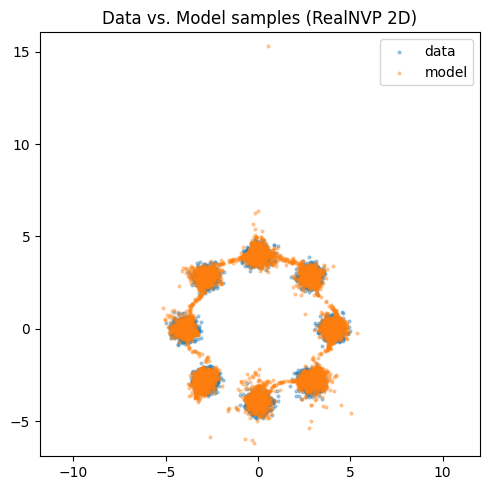

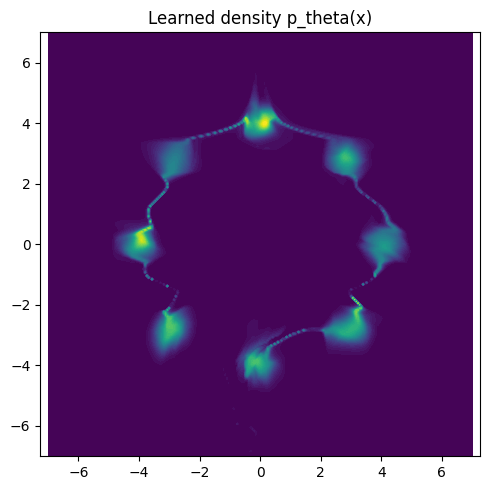

In [ ]:
# -------------------------
# 3) Training loop
# -------------------------
def train(
    steps=5000, batch_size=512, lr=1e-3, K=6, hidden=128, s_clamp=3.0,
    device=None, log_interval=500
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(0)

    flow = RealNVP2D(K=K, hidden=hidden, s_clamp=s_clamp).to(device)
    opt = torch.optim.Adam(flow.parameters(), lr=lr)

    for step in range(1, steps + 1):
        x = sample_8gaussians(batch_size, device=device)
        loss = -flow.log_prob(x).mean()  # NLL
        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(flow.parameters(), max_norm=10.0)
        opt.step()

        if step % log_interval == 0:
            with torch.no_grad():
                nll = -flow.log_prob(sample_8gaussians(2048, device=device)).mean().item()
            print(f"[step {step:5d}] train_NLL: {loss.item():.4f} | eval_NLL: {nll:.4f}")

    return flow

# -------------------------
# 4) Visualization helpers
# -------------------------
@torch.no_grad()
def plot_scatter_data_and_model(flow, n=4000, device=None):
    device = device or next(flow.parameters()).device
    x_data = sample_8gaussians(n, device=device).cpu()
    x_model = flow.sample(n, device=device).cpu()

    plt.figure(figsize=(5, 5))
    plt.scatter(x_data[:, 0], x_data[:, 1], s=4, alpha=0.35, label="data")
    plt.scatter(x_model[:, 0], x_model[:, 1], s=4, alpha=0.35, label="model")
    plt.axis("equal")
    plt.legend()
    plt.title("Data vs. Model samples (RealNVP 2D)")
    plt.tight_layout()
    plt.show()

@torch.no_grad()
def plot_density_contour(flow, lim=7.0, grid_n=300, device=None):
    device = device or next(flow.parameters()).device
    xs = torch.linspace(-lim, lim, grid_n, device=device)
    ys = torch.linspace(-lim, lim, grid_n, device=device)
    X, Y = torch.meshgrid(xs, ys, indexing="xy")
    points = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

    # Chunked eval to save memory
    logp = torch.empty(points.size(0), device=device)
    chunk = 16384
    for i in range(0, points.size(0), chunk):
        logp[i:i+chunk] = flow.log_prob(points[i:i+chunk])
    Z = logp.reshape(grid_n, grid_n).exp().cpu()  # density

    plt.figure(figsize=(5, 5))
    plt.contourf(X.cpu(), Y.cpu(), Z, levels=50)
    plt.title("Learned density p_theta(x)")
    plt.axis("equal")
    plt.tight_layout()
    plt.show()



flow = train(steps=5000, batch_size=512, lr=1e-3, K=6, hidden=128, s_clamp=3.0)
plot_scatter_data_and_model(flow, n=6000)
plot_density_contour(flow, lim=7.0, grid_n=250)

From the final results, we can see that the model was able to learn the location of the eight nodes.

## Problem 3.5
The inverse mapping for $y_a=x_a$ is simple and its inverse ise $x_a=y_a$. The inverse mapping for $y_b = x_b + t_{\theta}(x_a)$ is $x_b = y_b - t_{\theta}(x_a)$.

The forward for the Jacobian matrix can be computed as shown:
$$
T(y) = \begin{bmatrix} y_a \\ y_b \end{bmatrix} = \begin{bmatrix} x_a \\ x_b + t_{\theta}(x_a) \end{bmatrix}
$$
Then we can do the following:
$$
\nabla T(y) = \begin{bmatrix} I & 0 \\ \frac{dt_\theta}{dx_a} & I \end{bmatrix}
$$

The inverse for the Jacobian matrix can be computed as shown
$$
T^{-1}(y) = \begin{bmatrix} y_a \\ y_b - t_{\theta}(y_a) \end{bmatrix} 
$$
Then we can do the following:
$$
\nabla T^{-1}(y) = \begin{bmatrix} I & 0 \\ -\frac{dt_\theta}{dy_a} & I \end{bmatrix}
$$

Since the diagonal is only the Identity matrix, $det = I$. Thus, $log|det \nabla_y T^{-1}_{\theta}(y)| = log |I| = 0$.

## Problem 3.6
The inverse mapping can be defined as shown:
$$
x_a = y_a
$$

$$
\begin{align*}
y_b &= x_b \odot \exp(s_{\theta}(x_a)) + t_{\theta}(x_a) \\
y_b - t_{\theta}(x_a) &= x_b \odot \exp(s_{\theta}(x_a)) \\
y_b - t_{\theta}(x_a) \odot \exp(-s_{\theta}(x_a)) &= x_b
\end{align*}
$$

This is invertible due to $\exp(s_{\theta}(x_a)) > 0$ due to $s_{\theta}$ and $t_{\theta}$ which also ensures no 2 coordinates will collide.

Let's compute the following:
$$
\begin{align*}
\nabla_x T_{\theta}(x) &= \begin{bmatrix} x_a \\ x_b \odot \exp(s_{\theta}(x_a)) + t_{\theta}(x_a) \end{bmatrix} \\
 &= \begin{bmatrix} I & 0 \\ * & diag(\exp(s_{\theta}(x_a))) \end{bmatrix}
\end{align*}
$$
Where $*$ is something complex and I will keep it out here for simplicity as it will not affect the end result.

The matrix here will look similar for $T_{\theta}^{-1}(y)$ with the substitution of variables.

From this, the forward log-determinant $log |det \nabla_x T_{\theta}(x)| = \sum_j s_j(x_a)$ and the inverse log-determinant is $log |det \nabla_y T_{\theta}^{-1}(y)| = \sum_j s_j(y_a)$


# Part 2

## Problem 4.1

RUNNING DATASET: RINGS


Finished: rings | {'z_dim': 16, 'optimizer': 'adam', 'lr': 0.0002, 'n_critic': 1}


Finished: rings | {'z_dim': 16, 'optimizer': 'rmsprop', 'lr': 0.0001, 'n_critic': 1}


Finished: rings | {'z_dim': 16, 'optimizer': 'sgd', 'lr': 0.01, 'n_critic': 1}


Finished: rings | {'z_dim': 32, 'optimizer': 'rmsprop', 'lr': 5e-05, 'n_critic': 5}
RUNNING DATASET: 2SPIRALS


Finished: 2spirals | {'z_dim': 16, 'optimizer': 'adam', 'lr': 0.0002, 'n_critic': 1}


Finished: 2spirals | {'z_dim': 16, 'optimizer': 'rmsprop', 'lr': 0.0001, 'n_critic': 1}


Finished: 2spirals | {'z_dim': 16, 'optimizer': 'sgd', 'lr': 0.01, 'n_critic': 1}


Finished: 2spirals | {'z_dim': 32, 'optimizer': 'rmsprop', 'lr': 5e-05, 'n_critic': 5}


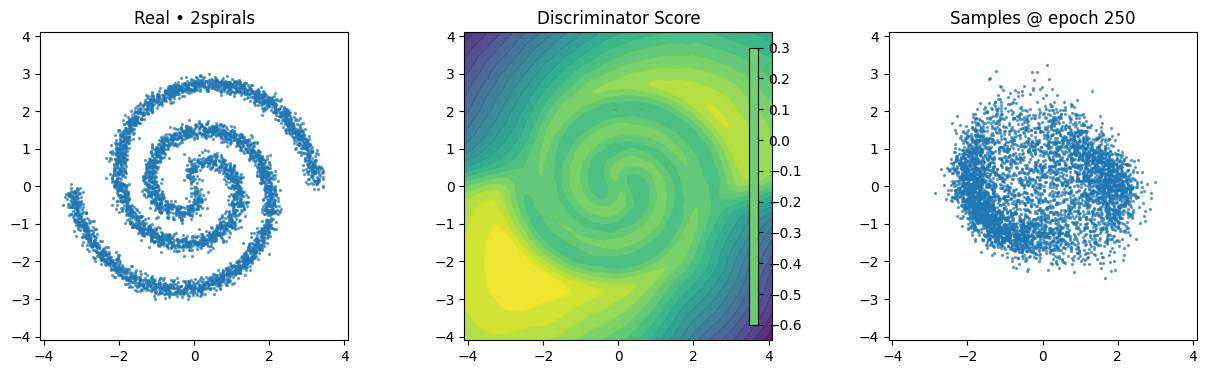

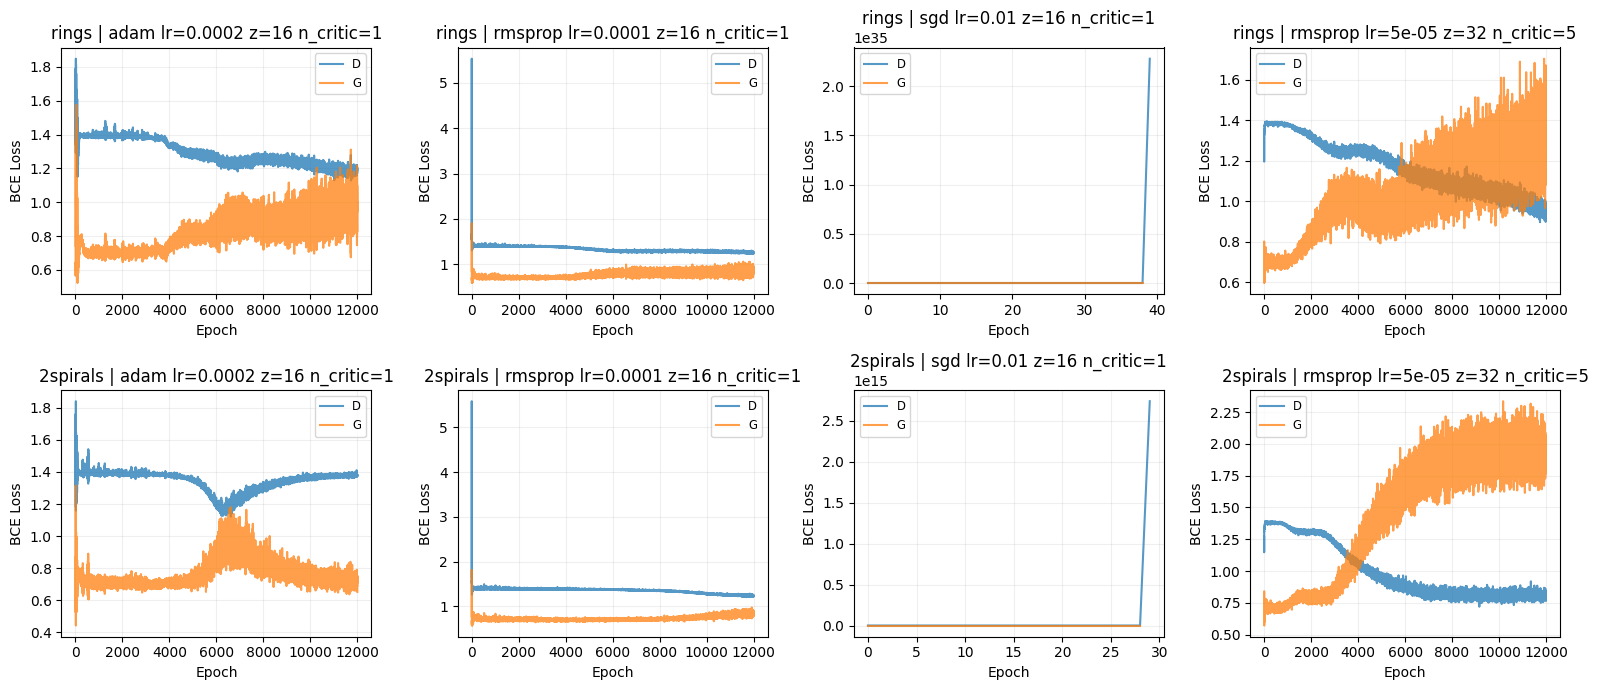

In [ ]:
#@title Q1

# === Visualization setup ===
VIZ_GRID_N = 140
xs, ys, grid_t = make_grid(n=VIZ_GRID_N, device=device)
push_snapshot = init_live_browser()

datasets = ["rings", "2spirals"]
parameters = [
    {
        "z_dim": 16,
        "optimizer": "adam",
        "lr": 2e-4,
        "n_critic": 1
    },
    {
        "z_dim": 16,
        "optimizer": "rmsprop",
        "lr": 1e-4,
        "n_critic": 1
    },
    {
        "z_dim": 16,
        "optimizer": "sgd",
        "lr": 1e-2,
        "n_critic": 1
    },
    {
        "z_dim": 32,
        "optimizer": "rmsprop",
        "lr": 5e-5,
        "n_critic": 5
    }
]
batch_size = 1024
dataset_size = 50000
beta1, beta2 = 0.5, 0.999
epochs = 250

run_results = []

for dataset in datasets:
  print(f"=========================================")
  print(f"RUNNING DATASET: {dataset.upper()}")
  print(f"=========================================")

  # loading data
  X_real = generate_data(dataset, batch_size=dataset_size, device="cpu")
  ds = TensorDataset(X_real)
  dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True,
                  num_workers=0, pin_memory=(device.type=="cuda"))

  for param in parameters:
    seed_everything()
    z_dim = param["z_dim"]
    lr = param["lr"]
    viz_noise = torch.randn(5000, z_dim, device=device)

    # making GAN
    G = MLPGenerator(z_dim=z_dim).to(device)
    D = MLPDiscriminator().to(device)
    G.apply(weights_init)
    D.apply(weights_init)

    if param["optimizer"] == "adam":
      opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))
      opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2))
    elif param["optimizer"] == "sgd":
      opt_G = torch.optim.SGD(G.parameters(), lr=lr, momentum=0.9)
      opt_D = torch.optim.SGD(D.parameters(), lr=lr, momentum=0.9)
    elif param["optimizer"] == "rmsprop":
      opt_G = torch.optim.RMSprop(G.parameters(), lr=lr)
      opt_D = torch.optim.RMSprop(D.parameters(), lr=lr)
    else:
      raise ValueError(f"Unsupported optimizer: {param['optimizer']}")

    bce = nn.BCEWithLogitsLoss()
    g_losses, d_losses = [], []

    for epoch in range(1, epochs+1):
        G.train(); D.train()
        pbar = tqdm(dl, desc=f"[{param['optimizer'].upper()}] Epoch {epoch}/{epochs}", leave=False)
        for real_batch, in pbar:
            real = real_batch.to(device, non_blocking=True)
            B = real.size(0)

            # ===== 1) Update Discriminator =====
            for _ in range(param["n_critic"]):
                z = torch.randn(B, z_dim, device=device)
                with torch.no_grad():
                    fake_detached = G(z)
                D_real = D(real)
                D_fake = D(fake_detached)
                d_loss = bce(D_real, torch.ones_like(D_real)) + bce(D_fake, torch.zeros_like(D_fake))
                opt_D.zero_grad(set_to_none=True)
                d_loss.backward()
                opt_D.step()

            # ===== 2) Update Generator (non-saturating) =====
            z = torch.randn(B, z_dim, device=device)
            fake = G(z)
            D_fake_for_G = D(fake)
            g_loss = bce(D_fake_for_G, torch.ones_like(D_fake_for_G))
            opt_G.zero_grad(set_to_none=True)
            g_loss.backward()
            opt_G.step()

            g_losses.append(g_loss.item()); d_losses.append(d_loss.item())
            pbar.set_postfix(d=f"{d_loss.item():.3f}", g=f"{g_loss.item():.3f}")

        if epoch % 10 == 0 or epoch == epochs:
            snap = capture_snapshot(G, D, X_real, viz_noise, xs, ys, grid_t, dataset, device, epoch)
            push_snapshot(snap)

    run_results.append({
        "dataset": dataset,
        "param": param,
        "g_losses": g_losses,
        "d_losses": d_losses,
    })

    print(f"Finished: {dataset} | {param}")

# Plot one graph per dataset + parameter combo after training
nrows = len(datasets)
ncols = len(parameters)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), squeeze=False)
for idx, run in enumerate(run_results):
    row = idx // ncols
    col = idx % ncols
    ax = axes[row][col]
    ax.plot(run["d_losses"], label="D", alpha=0.75)
    ax.plot(run["g_losses"], label="G", alpha=0.75)
    p = run["param"]
    ax.set_title(f"{run['dataset']} | {p['optimizer']} lr={p['lr']} z={p['z_dim']} n_critic={p['n_critic']}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")
    ax.legend(fontsize="small")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

RUNNING DATASET: RINGS


Finished: rings | {'gp_lambda': 1.0, 'n_critic': 2}


Finished: rings | {'gp_lambda': 0.1, 'n_critic': 1}


Finished: rings | {'gp_lambda': 10.0, 'n_critic': 1}


Finished: rings | {'gp_lambda': 10.0, 'n_critic': 5}
RUNNING DATASET: 2SPIRALS


Finished: 2spirals | {'gp_lambda': 1.0, 'n_critic': 2}


Finished: 2spirals | {'gp_lambda': 0.1, 'n_critic': 1}


Finished: 2spirals | {'gp_lambda': 10.0, 'n_critic': 1}


Finished: 2spirals | {'gp_lambda': 10.0, 'n_critic': 5}


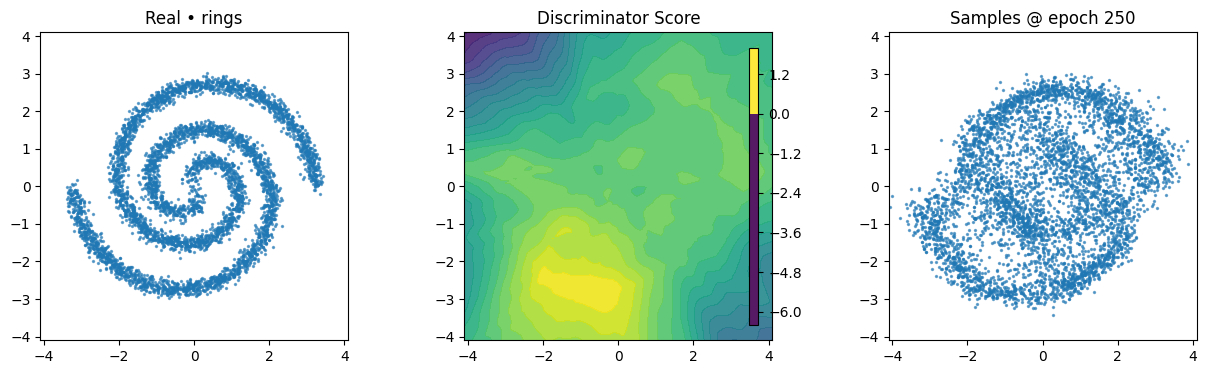

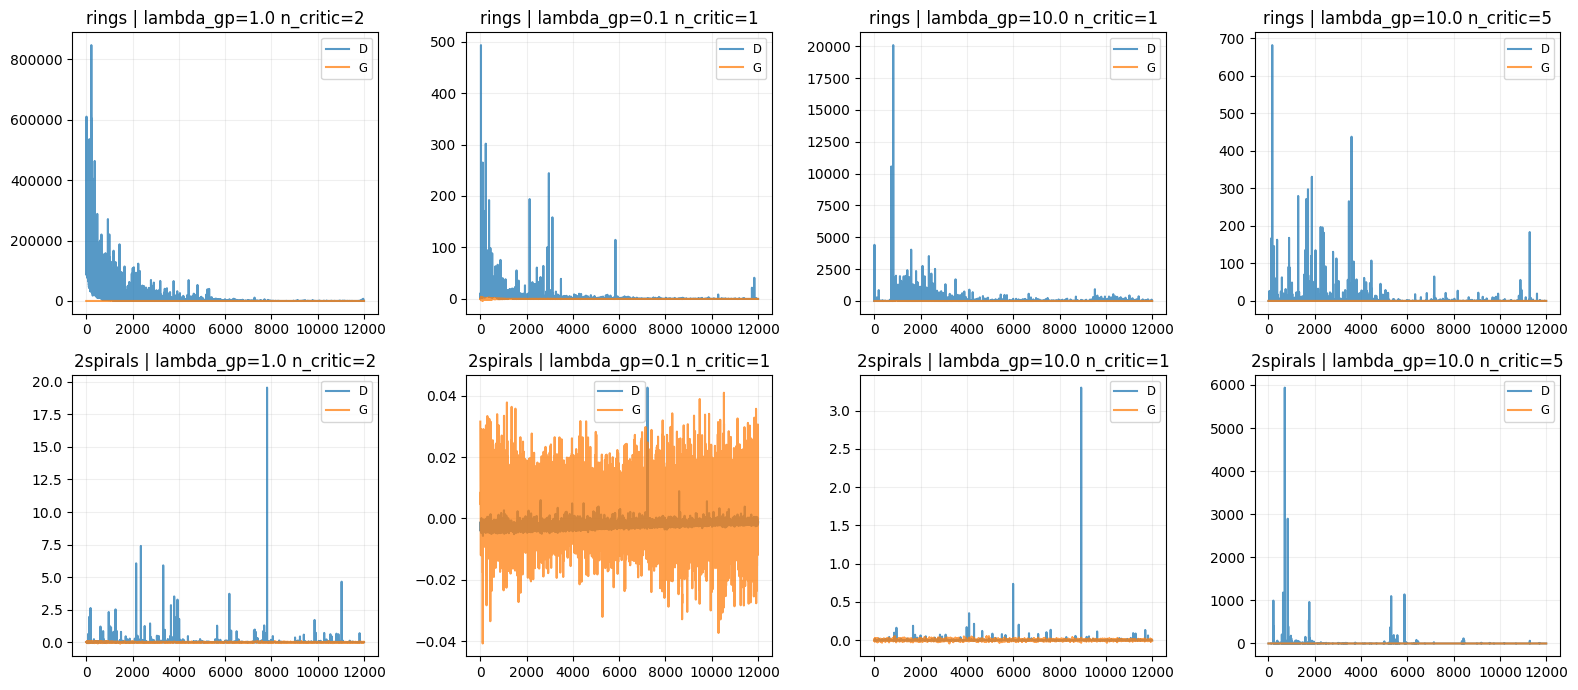

In [ ]:
# --- Visualization setup ---
VIZ_GRID_N = 140
xs, ys, grid_t = make_grid(n=VIZ_GRID_N, device=device)
viz_noise = torch.randn(5000, z_dim, device=device)
push_snapshot = init_live_browser()

# --- WGAN-GP settings ---
lr_G, lr_D = 1e-4, 1e-4
beta1, beta2 = 0.0, 0.9
epochs = 250
n_critic = 2
gp_lambda = 1.0

parameters = [
    {
        "gp_lambda": 1.0,
        "n_critic": 2
    },
    {
        "gp_lambda": 0.1,
        "n_critic": 1
    },
    {
        "gp_lambda": 10.0,
        "n_critic": 1
    },
    {
        "gp_lambda": 10.0,
        "n_critic": 5
    },
]

one_side_gp = True

# --- WGAN-GP gradient penalty ---
def gradient_penalty(D, real, fake, one_side=True, return_norm=False):
    B = real.size(0)
    mixing = torch.rand(B, *([1] * (real.dim() - 1)), device=real.device)
    x_hat = mixing * real + (1.0 - mixing) * fake
    x_hat.requires_grad_(True)

    d_hat = D(x_hat)
    grad_outputs = torch.ones_like(d_hat, device=x_hat.device)

    grads = torch.autograd.grad(
        outputs=d_hat,
        inputs=x_hat,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    gn = grads.flatten(1)
    if one_side:
        """
        Implement the one-sided variance GP
        """
        l2_norm = torch.sum(torch.square(gn))
        gp = torch.square(torch.clamp(l2_norm - 1.0, 0.0).mean())
    else:
        gp = (gn - 1.0).pow(2).mean()

    return (gp, gn.mean()) if return_norm else gp

run_results = []

for dataset in datasets:
  print(f"=========================================")
  print(f"RUNNING DATASET: {dataset.upper()}")
  print(f"=========================================")

  # loading data
  X_real = generate_data(dataset, batch_size=dataset_size, device="cpu")
  ds = TensorDataset(X_real)
  dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True,
                  num_workers=0, pin_memory=(device.type=="cuda"))

  for param in parameters:
    seed_everything()

    g_losses, d_losses = [], []

    for epoch in range(1, epochs+1):
        opt_G = torch.optim.Adam(G.parameters(), lr=lr_G, betas=(beta1, beta2))
        opt_D = torch.optim.Adam(D.parameters(), lr=lr_D, betas=(beta1, beta2))
        G.train(); D.train()
        pbar = tqdm(dl, desc=f"[Epoch {epoch}/{epochs}]", leave=False)

        for real_batch, in pbar:
            real = real_batch.to(device, non_blocking=True)     # (B,2)
            B = real.size(0)

            # ===== 1) Update Critic n_critic times =====
            for _ in range(param["n_critic"]):
                z = torch.randn(B, z_dim, device=device)
                with torch.no_grad():
                    fake_detached = G(z)

                D_real = D(real).view(-1)
                D_fake = D(fake_detached).view(-1)

                W = D_real.mean() - D_fake.mean()
                gp, gn_mean = gradient_penalty(
                    D, real, fake_detached,
                    one_side=one_side_gp,
                    return_norm=True
                )

                drift = 0.001 * (D_real.pow(2).mean())
                d_loss = (D_fake.mean() - D_real.mean()) + param["gp_lambda"] * gp + drift

                opt_D.zero_grad(set_to_none=True)
                d_loss.backward()
                opt_D.step()

            # ===== 2) Update Generator =====
            z = torch.randn(B, z_dim, device=device)
            fake = G(z)
            g_loss = - D(fake).view(-1).mean()

            opt_G.zero_grad(set_to_none=True)
            g_loss.backward()
            opt_G.step()

            g_losses.append(g_loss.item()); d_losses.append(d_loss.item())
            pbar.set_postfix(
                d=f"{d_loss.item():.3f}",
                g=f"{g_loss.item():.3f}",
                W=f"{W.item():.3f}",
                gp=f"{gp.item():.3f}",
                gn=f"{gn_mean.item():.2f}",
            )
            pbar.set_postfix(d=f"{d_loss.item():.3f}", g=f"{g_loss.item():.3f}")

        # Visualization every few epochs
        if epoch % 10 == 0 or epoch == epochs:
            snap = capture_snapshot(G, D, X_real, viz_noise, xs, ys, grid_t, data_type, device, epoch)
            push_snapshot(snap)

    run_results.append({
        "dataset": dataset,
        "param": param,
        "g_losses": g_losses,
        "d_losses": d_losses,
    })

    print(f"Finished: {dataset} | {param}")

# Plot one graph per dataset + parameter combo after training
nrows = len(datasets)
ncols = len(parameters)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), squeeze=False)
for idx, run in enumerate(run_results):
    row = idx // ncols
    col = idx % ncols
    ax = axes[row][col]
    ax.plot(run["d_losses"], label="D", alpha=0.75)
    ax.plot(run["g_losses"], label="G", alpha=0.75)
    p = run["param"]
    ax.set_title(f"{run['dataset']} | lambda_gp={p['gp_lambda']} n_critic={p['n_critic']}")
    ax.legend(fontsize="small")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

2) $\hat{x}$ is sampled by mixing the real data with the fake data. Here the code computes the gradient by using the torch library built-in gradient method that computes the gradient for us. This term is used when getting the L2 norm to compute the penalty. 

RUNNING DATASET: RINGS


Finished: rings | {'gp_lambda': 1.0, 'n_critic': 2}


Finished: rings | {'gp_lambda': 0.1, 'n_critic': 1}


Finished: rings | {'gp_lambda': 10.0, 'n_critic': 1}


Finished: rings | {'gp_lambda': 10.0, 'n_critic': 5}
RUNNING DATASET: 2SPIRALS


Finished: 2spirals | {'gp_lambda': 1.0, 'n_critic': 2}


Finished: 2spirals | {'gp_lambda': 0.1, 'n_critic': 1}


Finished: 2spirals | {'gp_lambda': 10.0, 'n_critic': 1}


Finished: 2spirals | {'gp_lambda': 10.0, 'n_critic': 5}


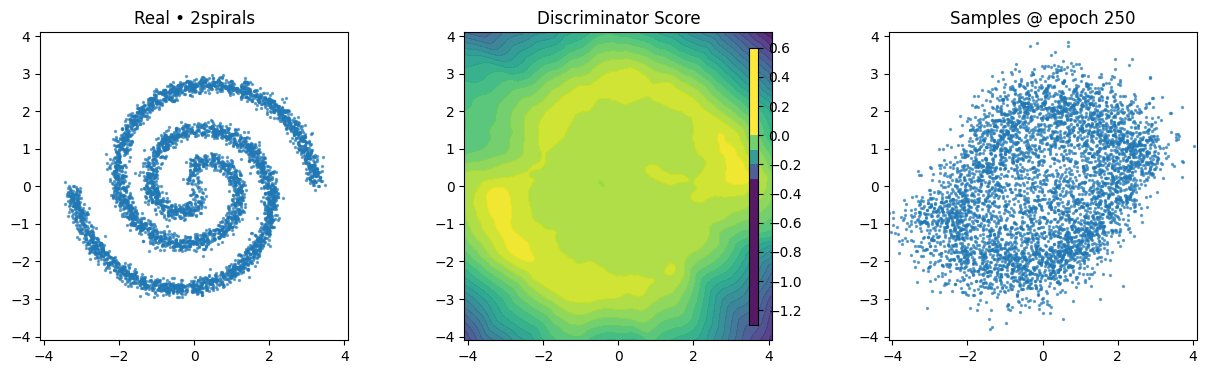

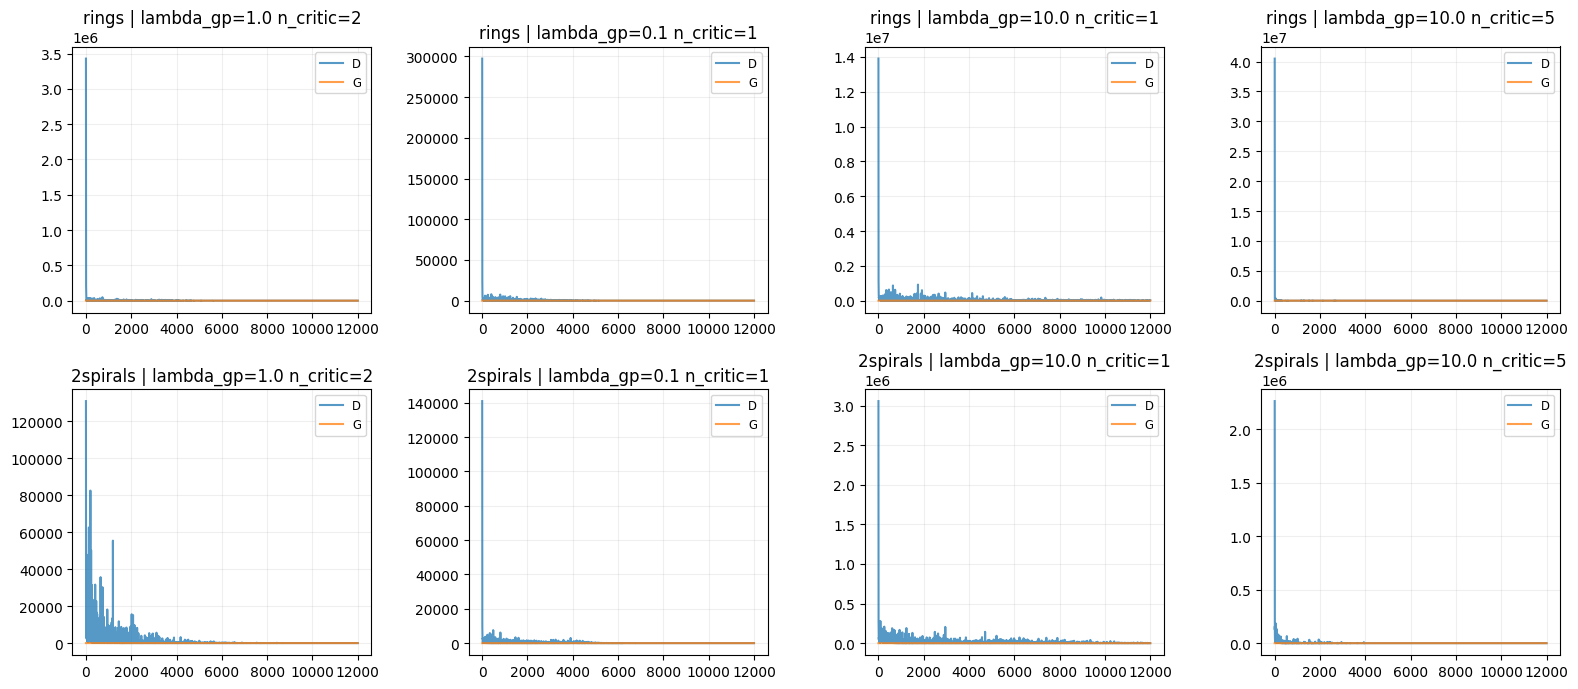

In [ ]:
# --- Visualization setup ---
VIZ_GRID_N = 140
xs, ys, grid_t = make_grid(n=VIZ_GRID_N, device=device)
viz_noise = torch.randn(5000, z_dim, device=device)
push_snapshot = init_live_browser()

# --- WGAN-GP settings ---
lr_G, lr_D = 1e-4, 1e-4
beta1, beta2 = 0.0, 0.9
epochs = 250
n_critic = 2
gp_lambda = 1.0

parameters = [
    {
        "gp_lambda": 1.0,
        "n_critic": 2
    },
    {
        "gp_lambda": 0.1,
        "n_critic": 1
    },
    {
        "gp_lambda": 10.0,
        "n_critic": 1
    },
    {
        "gp_lambda": 10.0,
        "n_critic": 5
    },
]

one_side_gp = True

# --- WGAN-GP gradient penalty ---
def gradient_penalty(D, real, fake, one_side=True, return_norm=False):
    B = real.size(0)
    mixing = torch.rand(B, *([1] * (real.dim() - 1)), device=real.device)
    x_hat = mixing * real + (1.0 - mixing) * fake
    x_hat.requires_grad_(True)

    d_hat = D(x_hat)
    grad_outputs = torch.ones_like(d_hat, device=x_hat.device)

    grads = torch.autograd.grad(
        outputs=d_hat,
        inputs=x_hat,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    gn = grads.flatten(1)
    if one_side:
        """
        Implement the one-sided variance GP
        """
        l2_norm = torch.sum(torch.square(gn))
        gp = torch.square(torch.clamp(l2_norm - 1.0, 0.0).mean())
    else:
        gp = (gn - 1.0).pow(2).mean()

    return (gp, gn.mean()) if return_norm else gp

run_results = []

for dataset in datasets:
  print(f"=========================================")
  print(f"RUNNING DATASET: {dataset.upper()}")
  print(f"=========================================")

  # loading data
  X_real = generate_data(dataset, batch_size=dataset_size, device="cpu")
  ds = TensorDataset(X_real)
  dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True,
                  num_workers=0, pin_memory=(device.type=="cuda"))

  for param in parameters:
    z_dim = 16
    G = MLPGenerator(z_dim=z_dim).to(device)
    D = MLPDiscriminator().to(device)
    G.apply(weights_init); D.apply(weights_init)

    opt_G = torch.optim.Adam(G.parameters(), lr=lr_G, betas=(beta1, beta2))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr_D, betas=(beta1, beta2))

    g_losses, d_losses = [], []

    for epoch in range(1, epochs+1):
        G.train(); D.train()
        pbar = tqdm(dl, desc=f"[Epoch {epoch}/{epochs}]", leave=False)

        for real_batch, in pbar:
            real = real_batch.to(device, non_blocking=True)     # (B,2)
            B = real.size(0)

            # ===== 1) Update Critic n_critic times =====
            for _ in range(param["n_critic"]):
                z = torch.randn(B, z_dim, device=device)
                with torch.no_grad():
                    fake_detached = G(z)

                D_real = D(real).view(-1)
                D_fake = D(fake_detached).view(-1)

                W = D_real.mean() - D_fake.mean()
                gp, gn_mean = gradient_penalty(
                    D, real, fake_detached,
                    one_side=one_side_gp,
                    return_norm=True
                )

                drift = 0.001 * (D_real.pow(2).mean())
                d_loss = (D_fake.mean() - D_real.mean()) + param["gp_lambda"] * gp + drift

                opt_D.zero_grad(set_to_none=True)
                d_loss.backward()
                opt_D.step()

            # ===== 2) Update Generator =====
            z = torch.randn(B, z_dim, device=device)
            fake = G(z)
            g_loss = - D(fake).view(-1).mean()

            opt_G.zero_grad(set_to_none=True)
            g_loss.backward()
            opt_G.step()

            g_losses.append(g_loss.item()); d_losses.append(d_loss.item())
            pbar.set_postfix(
                d=f"{d_loss.item():.3f}",
                g=f"{g_loss.item():.3f}",
                W=f"{W.item():.3f}",
                gp=f"{gp.item():.3f}",
                gn=f"{gn_mean.item():.2f}",
            )
            pbar.set_postfix(d=f"{d_loss.item():.3f}", g=f"{g_loss.item():.3f}")

        # Visualization every few epochs
        if epoch % 10 == 0 or epoch == epochs:
            snap = capture_snapshot(G, D, X_real, viz_noise, xs, ys, grid_t, dataset, device, epoch)
            push_snapshot(snap)

    run_results.append({
        "dataset": dataset,
        "param": param,
        "g_losses": g_losses,
        "d_losses": d_losses,
    })

    print(f"Finished: {dataset} | {param}")

# Plot one graph per dataset + parameter combo after training
nrows = len(datasets)
ncols = len(parameters)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), squeeze=False)
for idx, run in enumerate(run_results):
    row = idx // ncols
    col = idx % ncols
    ax = axes[row][col]
    ax.plot(run["d_losses"], label="D", alpha=0.75)
    ax.plot(run["g_losses"], label="G", alpha=0.75)
    p = run["param"]
    ax.set_title(f"{run['dataset']} | lambda_gp={p['gp_lambda']} n_critic={p['n_critic']}")
    ax.legend(fontsize="small")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

3) The best configuration from the experiment above is lambda_gp = 0.1 and n_critic = 1 for both datasets. This configuration has the least amount of spikes and converged more quickly compared to the other configurations. The gradient penalty improved the stability of training of the model. There were reduced oscillations, more consistent updates, and faster convergence to stability. However, the large penalty, as seen above, has an immense spike in the beginning causing less stable optimization. 

## Problem 4.2

For this problem, I wanted to find the best parameters before fully training the model. The following code takes 4 different parameters with the first parameter being the baseline parameter. It trains the parameters on 3 epochs and determines the best parameter to use.

In [ ]:
# === Train ===
parameters = [
    {
      "lr": 1e-4,
      "batch_size": 64,
      "n_critic": 5,
      "lambda_gp": 0.0,
      "dim": 16
    },
    {
        "lr": 1e-4,
        "batch_size": 64,
        "n_critic": 5,
        "lambda_gp": 10.0,
        "dim": 16,
    },
    {
        "lr": 2e-4,
        "batch_size": 64,
        "n_critic": 5,
        "lambda_gp": 0.1,
        "dim": 32,
    },
    {
        "lr": 2e-4,
        "batch_size": 128,
        "n_critic": 1,
        "lambda_gp": 10.0,
        "dim": 16,
    }
]

results = []
EPOCHS = 30

for param in parameters:
  train_loader, _ = get_mnist_dataloaders(batch_size=param["batch_size"])
  LR = param["lr"]
  GP_WEIGHT = param["lambda_gp"]
  CRITIC_ITERS = param["n_critic"]
  DIM = param["dim"]
  G = Generator(img_size=IMG_SIZE, latent_dim=LATENT_DIM, dim=DIM).to(device)
  D = Discriminator(img_size=IMG_SIZE, dim=DIM).to(device)

  G_opt = torch.optim.Adam(G.parameters(), lr=LR, betas=BETAS)
  D_opt = torch.optim.Adam(D.parameters(), lr=LR, betas=BETAS)

  trainer = Trainer(G, D, G_opt, D_opt,
                    gp_weight=GP_WEIGHT,
                    critic_iterations=CRITIC_ITERS,
                    print_every=PRINT_EVERY,
                    use_cuda=(device.type=='cuda'))

  trainer.train(train_loader, epochs=EPOCHS,
                save_training_gif=False,
                gif_every_epoch=False,
                gif_name=f'training_{dataset_name}_{EPOCHS}e.gif')

  score = trainer.losses['G'][-1]

  G.eval()

  with torch.no_grad():
      z = torch.randn(64, LATENT_DIM, device=device)
      fake = G(z).cpu()

  results.append({
      "param": param,
      "trainer": trainer,
      "generator": G,
      "samples": fake,
      "score": trainer.losses['G'][-1]
  })



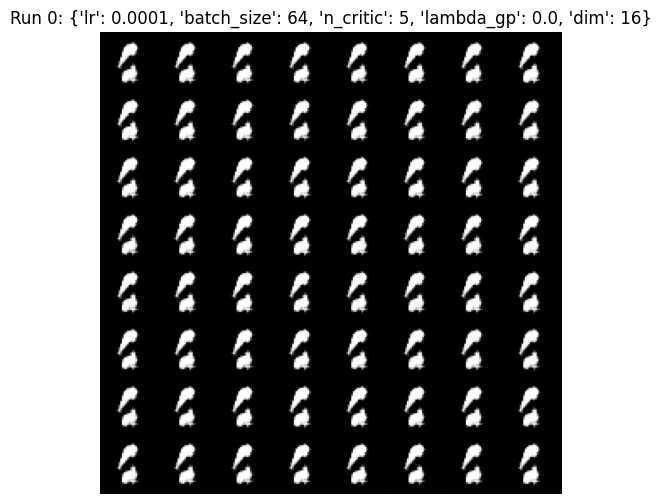

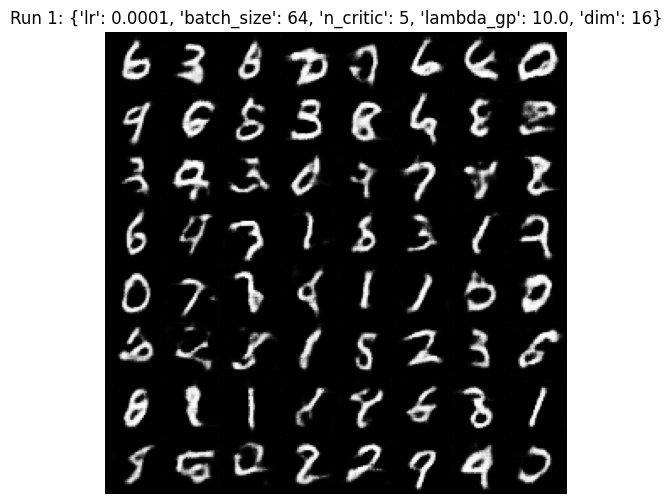

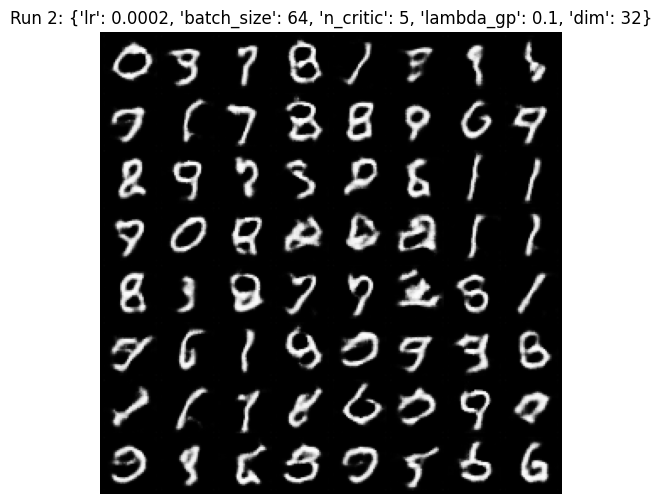

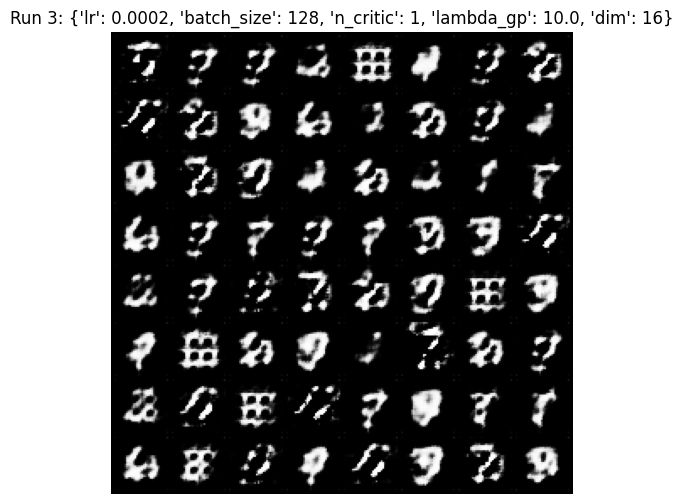

In [ ]:
import torchvision
for i, result in enumerate(results):
    samples = result["samples"]

    grid = torchvision.utils.make_grid(
        samples,
        nrow=8,
        normalize=True
    )

    plt.figure(figsize=(6,6))
    plt.imshow(grid.permute(1,2,0), cmap="gray")
    plt.axis("off")
    plt.title(f"Run {i}: {result['param']}")
    plt.show()

From the results above, the plot labeled with `Run 2` has the best results. Therefore, I will use those parameters to train the model to compare with the baseline parameter where `lambda_gp` = 0.

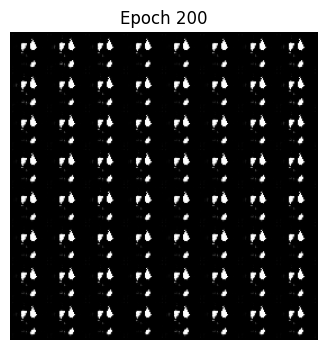

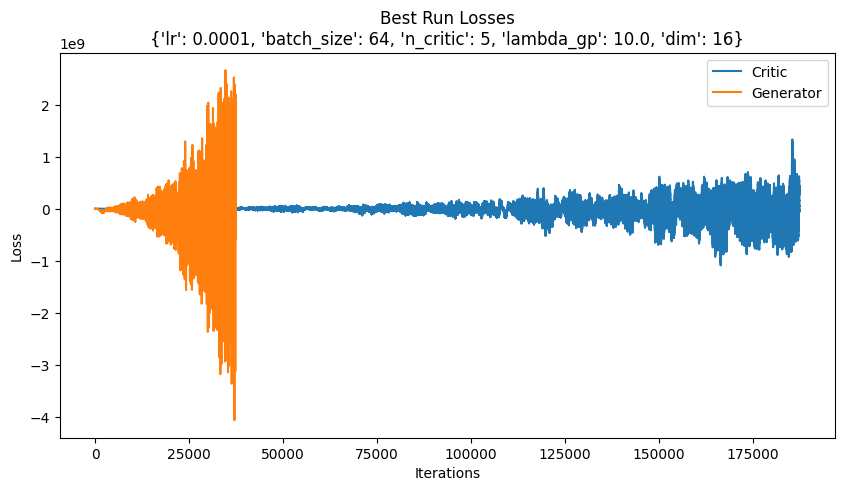

In [ ]:
# train with baseline parameter
baseline_param = {
  "lr": 1e-4,
  "batch_size": 64,
  "n_critic": 5,
  "lambda_gp": 0.0,
  "dim": 16
}

train_loader, _ = get_mnist_dataloaders(batch_size=baseline_param["batch_size"])
LR = baseline_param["lr"]
GP_WEIGHT = baseline_param["lambda_gp"]
CRITIC_ITERS = baseline_param["n_critic"]
DIM = baseline_param["dim"]
G = Generator(img_size=IMG_SIZE, latent_dim=LATENT_DIM, dim=DIM).to(device)
D = Discriminator(img_size=IMG_SIZE, dim=DIM).to(device)

G_opt = torch.optim.Adam(G.parameters(), lr=LR, betas=BETAS)
D_opt = torch.optim.Adam(D.parameters(), lr=LR, betas=BETAS)

trainer = Trainer(G, D, G_opt, D_opt,
                  gp_weight=GP_WEIGHT,
                  critic_iterations=CRITIC_ITERS,
                  print_every=PRINT_EVERY,
                  use_cuda=(device.type=='cuda'))

trainer.train(train_loader, epochs=EPOCHS,
              save_training_gif=True,
              gif_every_epoch=True,
              gif_name=f'training_{dataset_name}_{EPOCHS}e.gif')


plt.figure(figsize=(10,5))

plt.plot(trainer.losses['D'], label='Critic')
plt.plot(trainer.losses['G'], label='Generator')

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title(f"Best Run Losses\n{best_param}")
plt.legend()
plt.show()

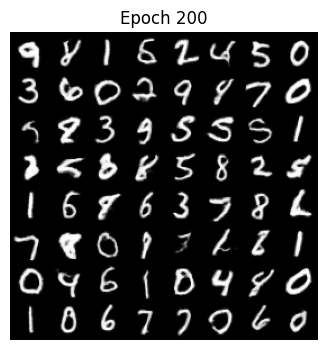

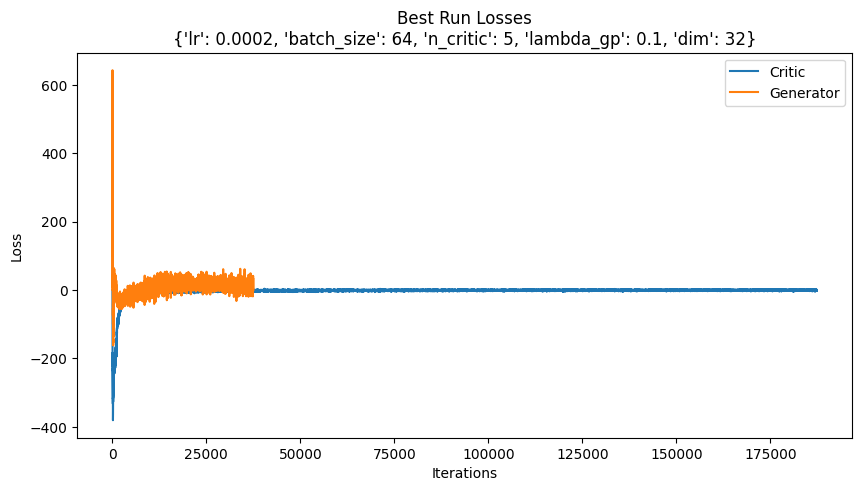

In [ ]:
best_idx = 2
best_result = results[best_idx]

best_param = best_result["param"]

# retrain with best parameters here
EPOCHS = 200
train_loader, _ = get_mnist_dataloaders(batch_size=best_param["batch_size"])
LR = best_param["lr"]
GP_WEIGHT = best_param["lambda_gp"]
CRITIC_ITERS = best_param["n_critic"]
DIM = best_param["dim"]
G = Generator(img_size=IMG_SIZE, latent_dim=LATENT_DIM, dim=DIM).to(device)
D = Discriminator(img_size=IMG_SIZE, dim=DIM).to(device)

G_opt = torch.optim.Adam(G.parameters(), lr=LR, betas=BETAS)
D_opt = torch.optim.Adam(D.parameters(), lr=LR, betas=BETAS)

trainer = Trainer(G, D, G_opt, D_opt,
                  gp_weight=GP_WEIGHT,
                  critic_iterations=CRITIC_ITERS,
                  print_every=PRINT_EVERY,
                  use_cuda=(device.type=='cuda'))

trainer.train(train_loader, epochs=EPOCHS,
              save_training_gif=True,
              gif_every_epoch=True,
              gif_name=f'training_{dataset_name}_{EPOCHS}e.gif')


plt.figure(figsize=(10,5))

plt.plot(trainer.losses['D'], label='Critic')
plt.plot(trainer.losses['G'], label='Generator')

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title(f"Best Run Losses\n{best_param}")
plt.legend()
plt.show()

The gradient penalty changes the training by making the training more stable and enforcing the Lipschitz constraint more directly on the critic. From the results above, we can see that the run without a gradient penalty has unstable optimization. There were a lot of fluctuations and oscillations rather than a smooth change. The training was more likely to collapse; hence, the resulting image did not show any digits. In the run with the gradient penalty, the critic loss was able to penalize gradient norms to slow for a smoother and more stable training. The generator was able to improve more steadily and the resulting sample quality is able to produce sharper images of the digits. 

## Problem 4.11
Let $F_1 = {f(x) = mx | m \in \{-1, 1\}}$. Consider $g(x)$ to be a flipped version of $f(x)$, therefore, $g(x) = -f(x) = -mx$. We know $g(x)$ is a linear function in the realm of $F$, $f(x)$ can be flipped without leaving its function class. If we let $m \in \{0, 1\}$, the outcome may not be true. Then, $g(x) = -f(x) = -mx | m \in \{-1, 0\}$. With this new definition, we can see that $g(x)$ being the flipped version of $f(x)$ does not lie in the original function class. Thus, we cannot flip the sign for this function class. With these 2 function definitions, it can be classified as symmetric function class and asymmetric function class. When a function is symmetric, the absolute value is not needed in the IPM formula due to the function inherently perserving the absolute value. Whereas, the asymmetric function does not adhere to this. Which means the function would need the absolute value to ensure that the IPM forumla returns a valid metric.